In [1]:
import joblib
from scipy import sparse
import pandas as pd

lr = joblib.load("../models/logistic_regression.joblib")
preprocessor = joblib.load("../models/preprocessor.joblib")
feature_names = joblib.load("../models/feature_names.joblib")
X_train_resampled = sparse.load_npz("../data/processed/X_train_resampled.npz")
X_test_transformed = sparse.load_npz("../data/processed/X_test_transformed.npz")
y_test = pd.read_csv("../data/processed/y_test.csv")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


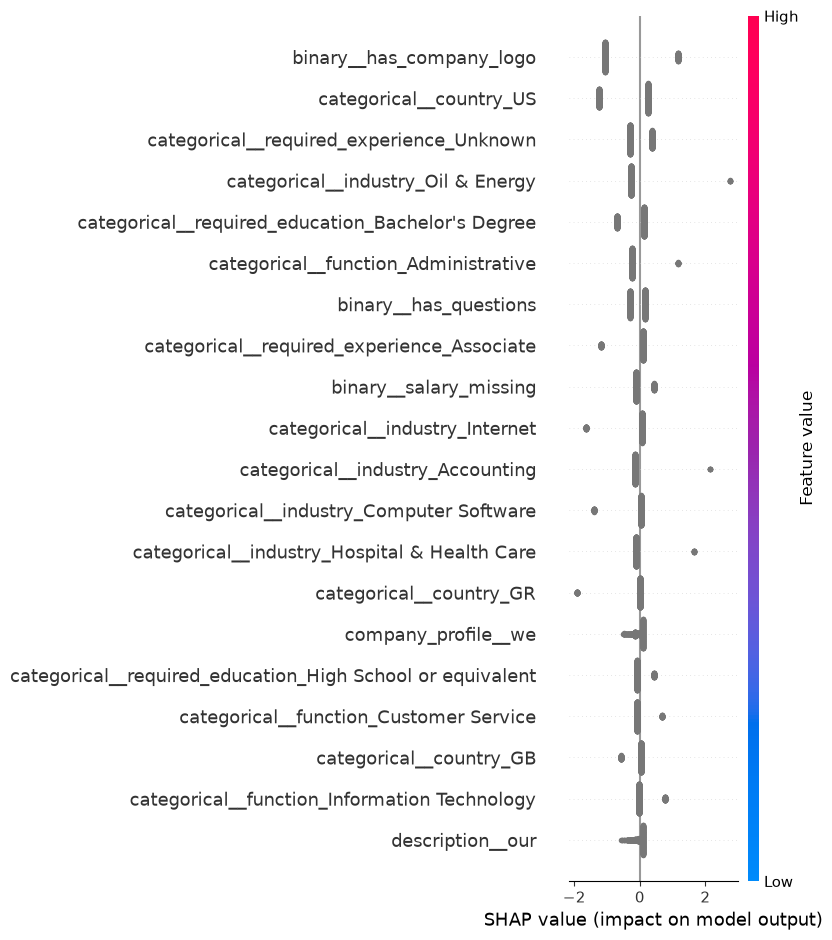

In [2]:
import shap
# 1. Background sample (LinearExplainer doesn't need the full training set)
background = shap.sample(X_train_resampled, 200, random_state=42)

# 2. Build the explainer
explainer = shap.LinearExplainer(lr, background)

# 3. Compute SHAP values on a sample of the test set (full set is fine too, LR is fast)
X_test_sample = X_test_transformed[:500]
shap_values = explainer.shap_values(X_test_sample)

# 4. Global summary plot (top tokens overall)
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, max_display=20)

In [3]:
# Map each feature to its source field
import numpy as np
def get_field(fname):
    for col in ['title', 'company_profile', 'description', 'requirements', 'benefits']:
        if fname.startswith(col + '__'):
            return col
    if fname.startswith('categorical__'):
        return 'categorical'
    if fname.startswith('binary__'):
        return 'binary'
    return 'other'

field_map = pd.Series([get_field(f) for f in feature_names], index=feature_names)

# Mean |SHAP| per feature, then summed per field
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
shap_df['field'] = shap_df['feature'].map(field_map)

field_importance = shap_df.groupby('field')['mean_abs_shap'].sum().sort_values(ascending=False)
print(field_importance)

field
description        5.706975
categorical        4.823841
company_profile    4.106113
requirements       3.247140
title              1.852923
benefits           1.765869
binary             1.535642
Name: mean_abs_shap, dtype: float64


In [4]:
shap.initjs()
idx = 0  # pick a true-positive fraud case

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_sample[idx].toarray().flatten(),
    feature_names=feature_names
)

Prediction: FRAUDULENT  (fraud probability: 0.992)


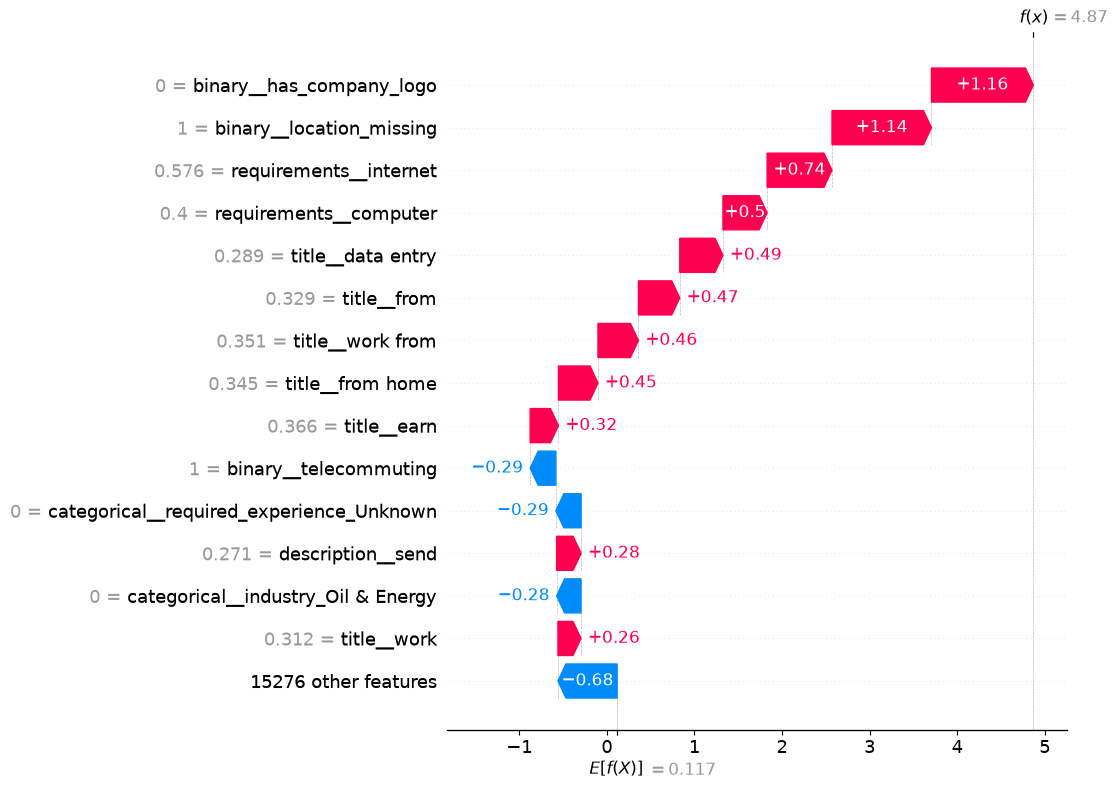

In [5]:
import pandas as pd

# 1. Create a single example posting - match your original column structure
example = pd.DataFrame([{
    'title': 'Work From Home Data Entry - Earn $5000/week',
    'company_profile': '',
    'description': 'No experience needed! Just fill out forms and get paid daily. Send your bank details to get started immediately.',
    'requirements': 'Must have a computer and internet.',
    'benefits': 'Flexible hours, guaranteed income.',
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'Other',
    'required_experience': 'Not Applicable',
    'required_education': 'Unknown',
    'industry': 'Unknown',
    'function': 'Unknown',
    'salary_missing': 1,
    'location_missing': 1,
    'country': 'US'
}])

# 2. Fill NaNs same way you did for training (already done above, but keep consistent)
for col in ['title','company_profile','description','requirements','benefits']:
    example[col] = example[col].fillna('')

# 3. Transform using your SAVED preprocessor (not fit again — just transform)
preprocessor = joblib.load("../models/preprocessor.joblib")
example_transformed = preprocessor.transform(example)

# 4. Predict
pred = lr.predict(example_transformed)[0]
proba = lr.predict_proba(example_transformed)[0][1]
print(f"Prediction: {'FRAUDULENT' if pred == 1 else 'Legitimate'}  (fraud probability: {proba:.3f})")

# 5. SHAP explanation for this single example
example_shap = explainer.shap_values(example_transformed)

shap.plots.waterfall(
    shap.Explanation(
        values=example_shap[0],
        base_values=explainer.expected_value,
        data=example_transformed.toarray().flatten(),
        feature_names=feature_names
    ),
    max_display=15
)

Prediction: Legitimate  (fraud probability: 0.000)


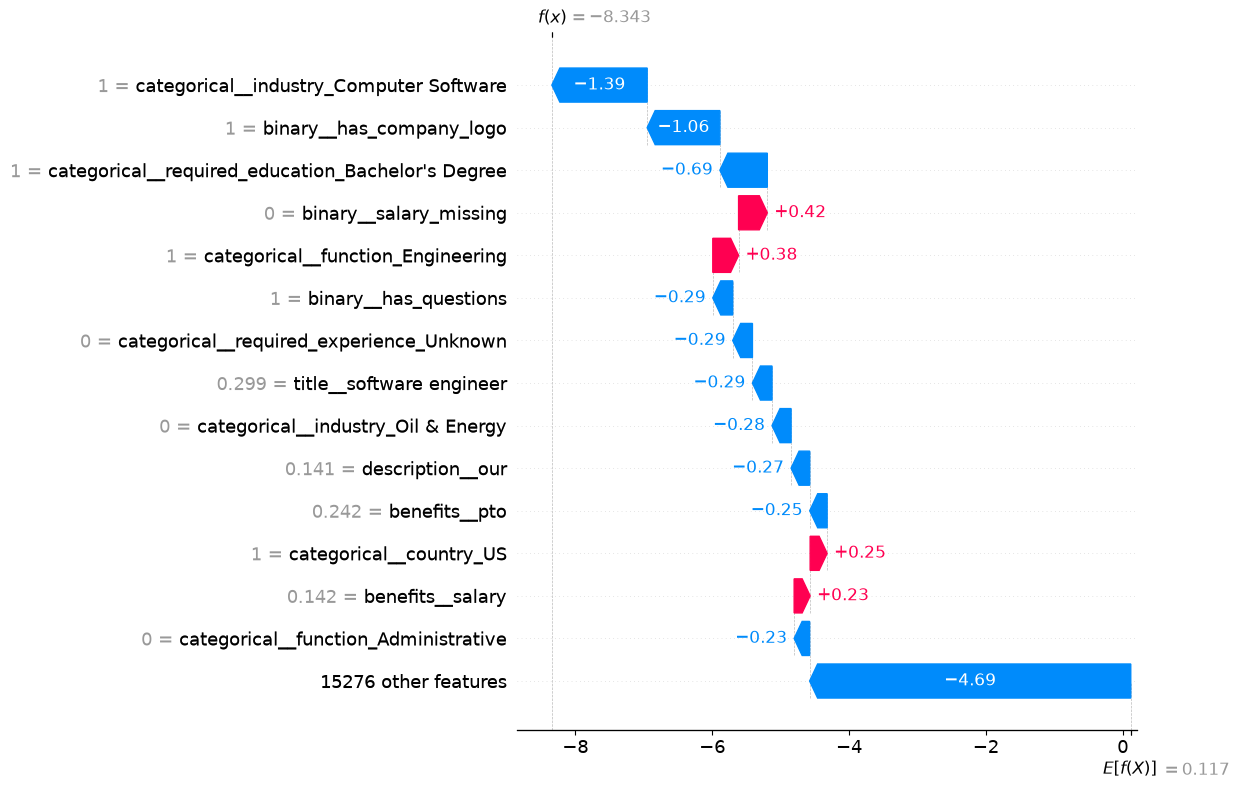

In [6]:
legit_example = pd.DataFrame([{
    'title': 'Senior Software Engineer - Backend Systems',
    'company_profile': 'Acme Technologies is a leading provider of cloud infrastructure solutions, serving over 500 enterprise clients worldwide. Founded in 2010, we are headquartered in Austin, Texas with offices in three countries.',
    'description': 'We are seeking an experienced Senior Software Engineer to join our backend platform team. You will design, build, and maintain scalable microservices that power our core product. You will collaborate closely with product managers and other engineers, participate in code reviews, and mentor junior team members. This role reports to the Engineering Manager and is based in our Austin office with hybrid flexibility.',
    'requirements': "Bachelor's degree in Computer Science or related field. 5+ years of professional software engineering experience. Strong proficiency in Python or Java. Experience with distributed systems, REST APIs, and cloud platforms (AWS/GCP). Excellent communication and collaboration skills.",
    'benefits': 'Competitive salary, comprehensive health/dental/vision insurance, 401(k) matching, 20 days PTO, annual learning stipend, hybrid work model.',
    'telecommuting': 0,
    'has_company_logo': 1,
    'has_questions': 1,
    'employment_type': 'Full-time',
    'required_experience': 'Mid-Senior level',
    'required_education': "Bachelor's Degree",
    'industry': 'Computer Software',
    'function': 'Engineering',
    'salary_missing': 0,
    'location_missing': 0,
    'country': 'US'
}])

for col in ['title','company_profile','description','requirements','benefits']:
    legit_example[col] = legit_example[col].fillna('')

legit_transformed = preprocessor.transform(legit_example)

pred = lr.predict(legit_transformed)[0]
proba = lr.predict_proba(legit_transformed)[0][1]
print(f"Prediction: {'FRAUDULENT' if pred == 1 else 'Legitimate'}  (fraud probability: {proba:.3f})")

legit_shap = explainer.shap_values(legit_transformed)

shap.plots.waterfall(
    shap.Explanation(
        values=legit_shap[0],
        base_values=explainer.expected_value,
        data=legit_transformed.toarray().flatten(),
        feature_names=feature_names
    ),
    max_display=15
)

In [7]:
y_test_arr = y_test.values.flatten()
y_pred_full = lr.predict(X_test_transformed)

# False negatives: actual fraud (1), predicted legit (0)
fn_indices = np.where((y_test_arr == 1) & (y_pred_full == 0))[0]
print(f"Number of false negatives: {len(fn_indices)}")
print(fn_indices[:10])

Number of false negatives: 16
[ 167  341  510  727  853 1006 1452 1534 2123 2268]


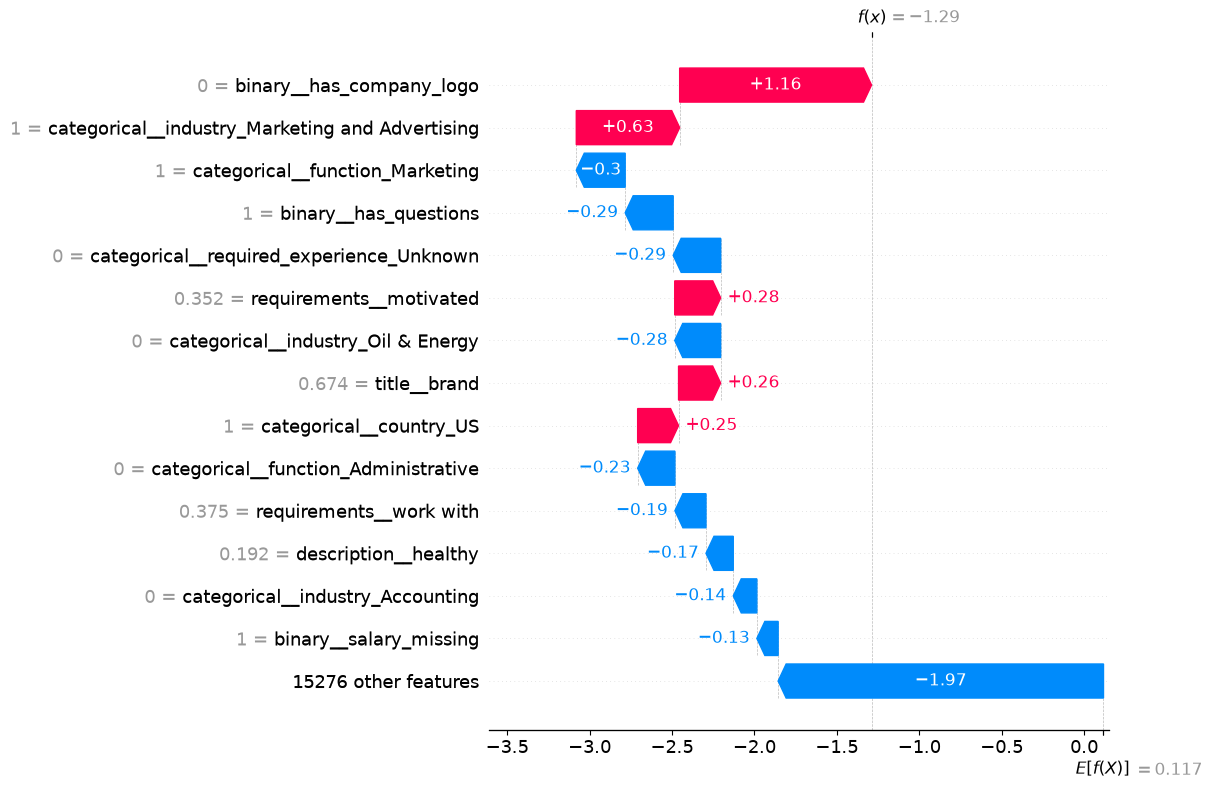

In [8]:
fn_idx = fn_indices[0]
fn_shap = explainer.shap_values(X_test_transformed[fn_idx])

shap.plots.waterfall(
    shap.Explanation(
        values=fn_shap[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[fn_idx].toarray().flatten(),
        feature_names=feature_names
    ),
    max_display=15
)